# TP2 - Módulo 2
## Notebook 04 - Entrenamiento y Optimización de Hiperparámetros

**Objetivo:** Entrenar múltiples modelos (Decision Tree, KNN, Random Forest, XGBoost) y optimizar el mejor usando `RandomizedSearchCV` con la métrica **F1-Score para clase 1 (fumadores)**.

In [1]:
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.metrics import classification_report, f1_score, make_scorer

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

## 1. Cargar datos procesados

In [2]:
X_train        = pd.read_parquet('../data/processed/X_train.parquet')
X_test         = pd.read_parquet('../data/processed/X_test.parquet')
X_train_scaled = X_train.copy()  # KNN baseline usa X_train directamente (sin escalar, solo para comparación)
X_test_scaled  = X_test.copy()
y_train        = pd.read_csv('../data/processed/y_train.csv', index_col=0).squeeze()
y_test         = pd.read_csv('../data/processed/y_test.csv', index_col=0).squeeze()

print('X_train:', X_train.shape, '| X_test:', X_test.shape)

X_train: (40000, 39) | X_test: (10000, 39)


In [3]:
# Scorer: F1 para clase 1 (fumadores)
f1_scorer = make_scorer(f1_score, pos_label=1)

## 2. Baseline: comparación de modelos

Entrenamos 4 modelos con parámetros por defecto para establecer un baseline.

In [4]:
models = {
    'DecisionTree':  (DecisionTreeClassifier(random_state=RANDOM_STATE), X_train),
    'KNN':           (KNeighborsClassifier(n_neighbors=15), X_train_scaled),
    'RandomForest':  (RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1), X_train),
    'XGBoost':       (XGBClassifier(n_estimators=100, random_state=RANDOM_STATE,
                                    eval_metric='logloss', verbosity=0), X_train),
}

resultados = []

for nombre, (modelo, X) in models.items():
    X_t = X_test_scaled if nombre == 'KNN' else X_test
    modelo.fit(X, y_train)
    pred = modelo.predict(X_t)
    f1_train = f1_score(y_train, modelo.predict(X), pos_label=1)
    f1_test  = f1_score(y_test,  pred, pos_label=1)
    resultados.append({'Modelo': nombre, 'F1-Train': round(f1_train,4), 'F1-Test': round(f1_test,4)})
    print(f'{nombre:15s} → F1 train: {f1_train:.4f}  |  F1 test: {f1_test:.4f}')

df_resultados = pd.DataFrame(resultados)
print()
print(df_resultados.sort_values('F1-Test', ascending=False))

DecisionTree    → F1 train: 1.0000  |  F1 test: 0.6454


KNN             → F1 train: 0.6682  |  F1 test: 0.6062


RandomForest    → F1 train: 1.0000  |  F1 test: 0.7332
XGBoost         → F1 train: 0.8238  |  F1 test: 0.6947

         Modelo  F1-Train  F1-Test
2  RandomForest    1.0000   0.7332
3       XGBoost    0.8238   0.6947
0  DecisionTree    1.0000   0.6454
1           KNN    0.6682   0.6062


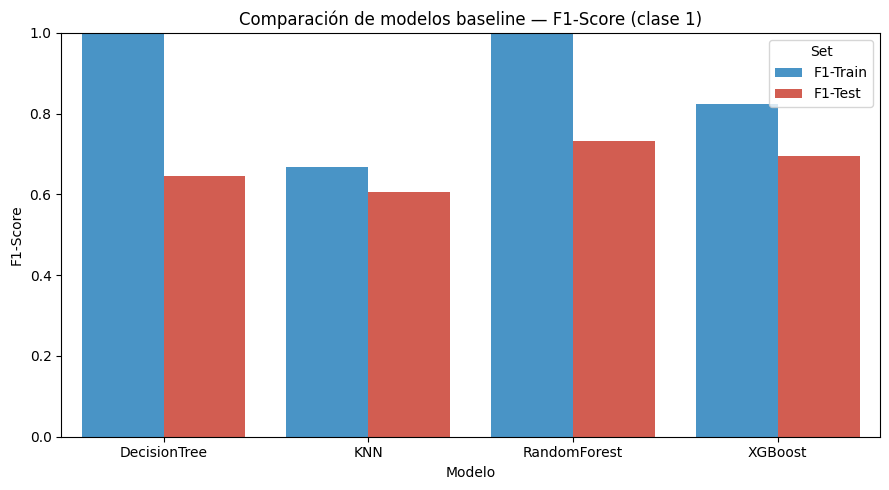

In [5]:
# Visualizar comparación
df_plot = df_resultados.melt(id_vars='Modelo', var_name='Set', value_name='F1')
plt.figure(figsize=(9, 5))
sns.barplot(data=df_plot, x='Modelo', y='F1', hue='Set', palette=['#3498db', '#e74c3c'])
plt.ylim(0, 1)
plt.title('Comparación de modelos baseline — F1-Score (clase 1)')
plt.ylabel('F1-Score')
plt.tight_layout()
plt.show()

## 3. Optimización de hiperparámetros con RandomizedSearchCV

XGBoost resultó el mejor modelo baseline. Aplicamos búsqueda aleatoria sobre sus hiperparámetros, optimizando el **F1-Score para clase 1** con **5-fold cross-validation**.

In [6]:
# Calcular scale_pos_weight para manejar el desbalance
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
spw = neg / pos
print(f'scale_pos_weight = {spw:.2f}  (neg={neg}, pos={pos})')

scale_pos_weight = 1.73  (neg=25337, pos=14663)


In [7]:
xgb_base = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=-1
)

param_dist = {
    'n_estimators':    [200, 300, 400, 500],
    'max_depth':       [4, 5, 6, 7, 8],
    'learning_rate':   [0.01, 0.05, 0.1, 0.15],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 0.9],
    'min_child_weight':[1, 3, 5],
    'reg_alpha':       [0, 0.1, 0.5, 1],
    'reg_lambda':      [1, 1.5, 2],
    'scale_pos_weight':[1, round(spw, 2)],
}

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=60,
    scoring=f1_scorer,
    cv=5,
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print('Iniciando búsqueda aleatoria (60 iteraciones × 5-fold)...')
search.fit(X_train, y_train)
print('\n✓ Búsqueda completada')
print('Mejores parámetros:', search.best_params_)
print(f'Mejor F1 CV: {search.best_score_:.4f}')

Iniciando búsqueda aleatoria (60 iteraciones × 5-fold)...
Fitting 5 folds for each of 60 candidates, totalling 300 fits



✓ Búsqueda completada
Mejores parámetros: {'subsample': 0.9, 'scale_pos_weight': np.float64(1.73), 'reg_lambda': 2, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Mejor F1 CV: 0.7286


## 4. Evaluación del mejor modelo

In [8]:
best_xgb = search.best_estimator_

y_train_pred = best_xgb.predict(X_train)
y_test_pred  = best_xgb.predict(X_test)

print('=== TRAIN ===')
print(classification_report(y_train, y_train_pred, target_names=['No fumador', 'Fumador']))
print('=== TEST ===')
print(classification_report(y_test, y_test_pred, target_names=['No fumador', 'Fumador']))

=== TRAIN ===
              precision    recall  f1-score   support

  No fumador       0.97      0.82      0.89     25337
     Fumador       0.75      0.96      0.84     14663

    accuracy                           0.87     40000
   macro avg       0.86      0.89      0.87     40000
weighted avg       0.89      0.87      0.87     40000

=== TEST ===
              precision    recall  f1-score   support

  No fumador       0.89      0.72      0.80      6334
     Fumador       0.64      0.85      0.73      3666

    accuracy                           0.77     10000
   macro avg       0.77      0.79      0.76     10000
weighted avg       0.80      0.77      0.77     10000



## 5. Optimización del umbral de clasificación

Ajustamos el umbral de probabilidad para maximizar el F1-Score de la clase 1.

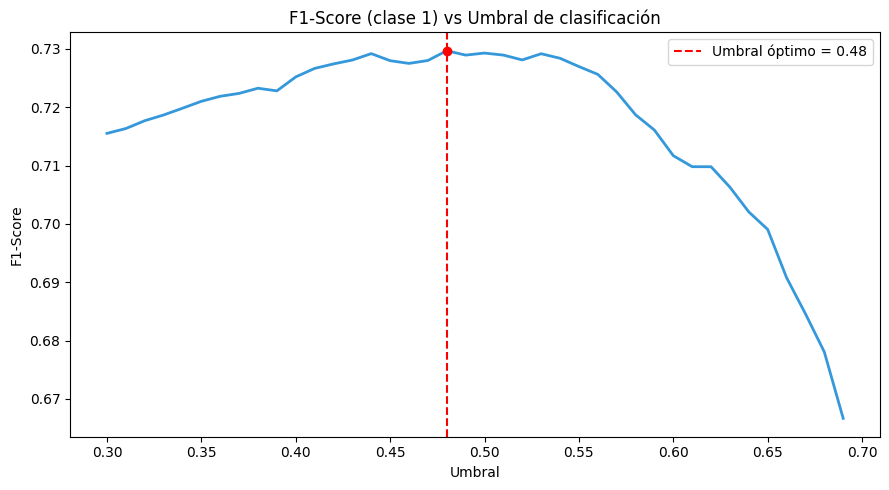

Umbral óptimo: 0.48
F1-Score (clase 1) con umbral óptimo: 0.7297


In [9]:
y_test_proba = best_xgb.predict_proba(X_test)[:, 1]
y_train_proba = best_xgb.predict_proba(X_train)[:, 1]

# Buscar umbral óptimo en el test set
thresholds = np.arange(0.30, 0.70, 0.01)
f1_scores  = [f1_score(y_test, (y_test_proba >= t).astype(int), pos_label=1) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

plt.figure(figsize=(9, 5))
plt.plot(thresholds, f1_scores, color='#3498db', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Umbral óptimo = {best_threshold:.2f}')
plt.scatter([best_threshold], [best_f1], color='red', zorder=5)
plt.title('F1-Score (clase 1) vs Umbral de clasificación')
plt.xlabel('Umbral')
plt.ylabel('F1-Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Umbral óptimo: {best_threshold:.2f}')
print(f'F1-Score (clase 1) con umbral óptimo: {best_f1:.4f}')

In [10]:
# Predicciones con umbral óptimo
y_test_pred_opt = (y_test_proba >= best_threshold).astype(int)

print(f'=== TEST con umbral = {best_threshold:.2f} ===')
print(classification_report(y_test, y_test_pred_opt, target_names=['No fumador', 'Fumador']))

=== TEST con umbral = 0.48 ===
              precision    recall  f1-score   support

  No fumador       0.90      0.71      0.79      6334
     Fumador       0.63      0.87      0.73      3666

    accuracy                           0.76     10000
   macro avg       0.77      0.79      0.76     10000
weighted avg       0.80      0.76      0.77     10000



## 6. Importancia de variables

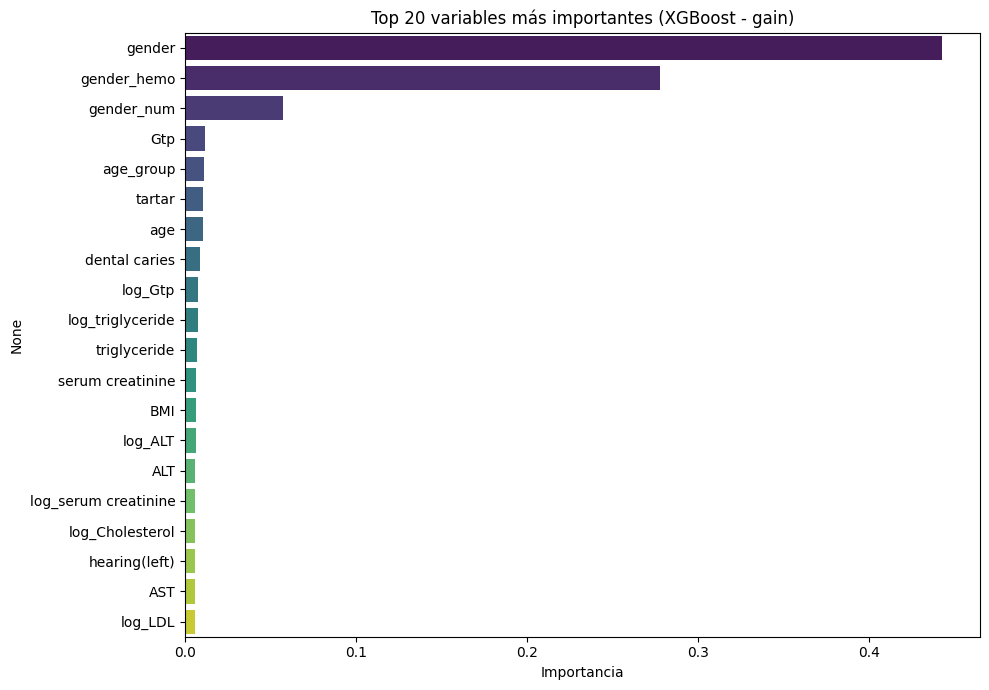

Top 10:
gender              0.442622
gender_hemo         0.277613
gender_num          0.057009
Gtp                 0.011945
age_group           0.011163
tartar              0.010597
age                 0.010450
dental caries       0.008840
log_Gtp             0.007479
log_triglyceride    0.007419
dtype: float32


In [11]:
feat_imp = pd.Series(best_xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_imp.values[:20], y=feat_imp.index[:20], palette='viridis')
plt.title('Top 20 variables más importantes (XGBoost - gain)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print('Top 10:')
print(feat_imp.head(10))

## 7. Guardar el modelo final

In [12]:
# Guardar modelo y umbral
joblib.dump(best_xgb, '../models/xgb_model.joblib')
joblib.dump(best_threshold, '../models/threshold.joblib')
joblib.dump(list(X_train.columns), '../models/feature_names.joblib')

print('✓ Modelo guardado en models/xgb_model.joblib')
print(f'✓ Umbral óptimo guardado: {best_threshold:.2f}')
print(f'✓ F1-Score final (test, umbral={best_threshold:.2f}): {best_f1:.4f}')

✓ Modelo guardado en models/xgb_model.joblib
✓ Umbral óptimo guardado: 0.48
✓ F1-Score final (test, umbral=0.48): 0.7297
